# Notebook 1 — Exploration, Research & Signal Identification

For the "how should BTC-MINI and ETH-MINI trade relative to each other" segment.

Data comes from `data/btc_eth_sample.csv` — treat it exactly like a live pull from the exchange (`GET /book/{product}` or the WebSocket stream, logged over time). It happens to have been produced by `generate_data.py` (same GBM model + shock/spread mechanics as the live exchange itself — see that file for details), but nothing below depends on that; swap the CSV for a real pull on the day and everything downstream still works.

**Goal of this notebook:** find the relationship between the two instruments, decide what "normal" looks like, and turn that into a concrete rule — when do we long, when do we short, and of *what*. That rule is the thing the next notebook wires up to the actual exchange API.

In [9]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path.cwd() / "data"

## Chart style

One shared axis for BTC/ETH (never dual-axis — the two contracts are sized to sit in the same ~$70–80 notional band precisely so they're directly comparable). Fixed categorical colors: BTC = blue, ETH = orange, spread = aqua.

In [10]:
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"

COLOR_BTC = "#2a78d6"
COLOR_ETH = "#eb6834"
COLOR_SPREAD = "#1baf7a"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRIDLINE,
    "axes.labelcolor": INK_SECONDARY,
    "axes.grid": True,
    "grid.color": GRIDLINE,
    "grid.linewidth": 1,
    "grid.linestyle": "-",
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Load the data

Reads the "live" price pull and the presenter's own record of when the scripted demo events landed (real live data wouldn't have this second file — it's here purely so *we* know what to expect when rehearsing).

In [11]:
df = pd.read_csv(DATA_DIR / "btc_eth_sample.csv", parse_dates=["timestamp"]).set_index("timestamp")
df["spread"] = df["btc"] - df["eth"]

events_path = DATA_DIR / "btc_eth_sample_events.csv"
if events_path.exists():
    events_df = pd.read_csv(events_path, parse_dates=["timestamp"])
    event_times = list(events_df["timestamp"])
    event_labels = list(events_df["label"])
else:
    event_times, event_labels = [], []

print(f"{len(df):,} rows, {df.index.min()} to {df.index.max()}")
df.head()

7,201 rows, 2026-09-07 09:00:00 to 2026-09-07 11:00:00


,btc,eth,spread
timestamp,,,
2026-09-07 09:00:00,77.498057,72.904647,4.593410
2026-09-07 09:00:01,77.496341,72.901783,4.594558
2026-09-07 09:00:02,77.489282,72.899844,4.589438
2026-09-07 09:00:03,77.497721,72.903698,4.594023
2026-09-07 09:00:04,77.505591,72.905960,4.599631


## Price series

Both contracts on one shared axis — that's the whole point of sizing them the way §2 of the build spec does: at ~$75 notional each, a roughly 1:1 contract count is dollar-neutral *today*, and you can watch that stop being exactly true as the real BTC/ETH ratio drifts.

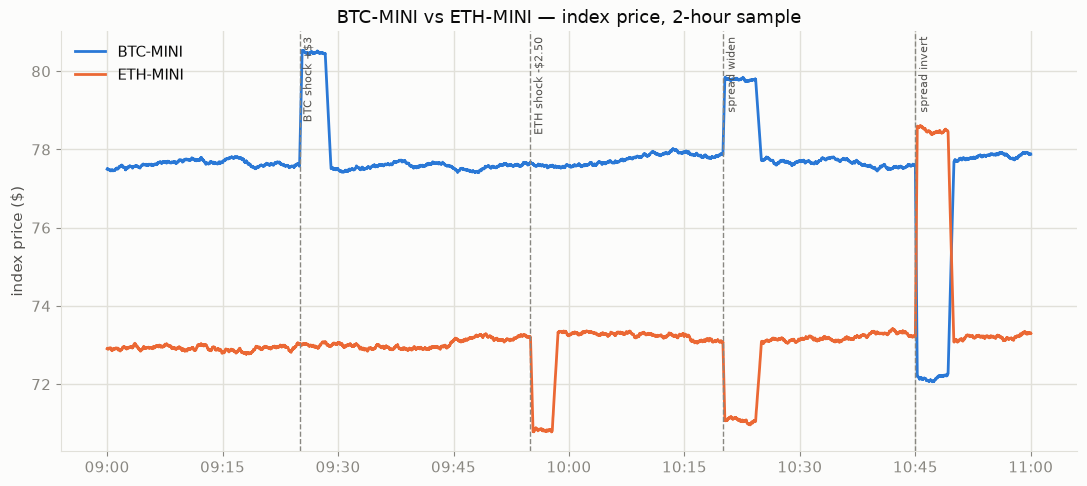

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df.index, df["btc"], color=COLOR_BTC, linewidth=2, label="BTC-MINI")
ax.plot(df.index, df["eth"], color=COLOR_ETH, linewidth=2, label="ETH-MINI")

for t, label in zip(event_times, event_labels):
    ax.axvline(t, color=INK_MUTED, linestyle="--", linewidth=1)
    ax.annotate(label, xy=(t, ax.get_ylim()[1]), xytext=(2, -4),
                textcoords="offset points", fontsize=8, color=INK_SECONDARY,
                rotation=90, va="top", ha="left")

ax.set_ylabel("index price ($)")
ax.set_title("BTC-MINI vs ETH-MINI — index price, 2-hour sample")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

## The spread

Defined the same way the exchange itself defines it internally (`IndexPriceService.trigger_spread_event`): `spread = BTC-MINI index − ETH-MINI index`, both already in contract-notional dollar terms. This is the thing students are meant to notice doesn't sit still.

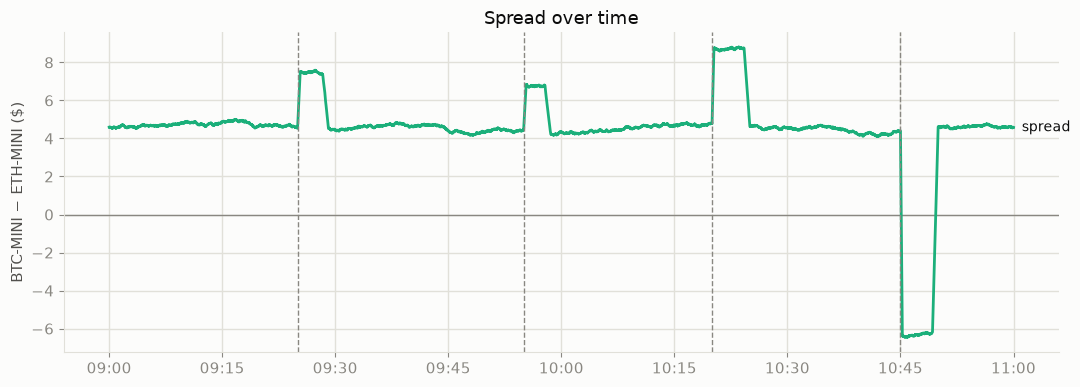

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.axhline(0, color=INK_MUTED, linewidth=1)
ax.plot(df.index, df["spread"], color=COLOR_SPREAD, linewidth=2)
ax.annotate("spread", xy=(df.index[-1], df["spread"].iloc[-1]), xytext=(6, 0),
            textcoords="offset points", fontsize=10, color=INK_PRIMARY, va="center")

for t, label in zip(event_times, event_labels):
    ax.axvline(t, color=INK_MUTED, linestyle="--", linewidth=1)

ax.set_ylabel("BTC-MINI − ETH-MINI ($)")
ax.set_title("Spread over time")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.tight_layout()
plt.show()

## Distribution of the spread

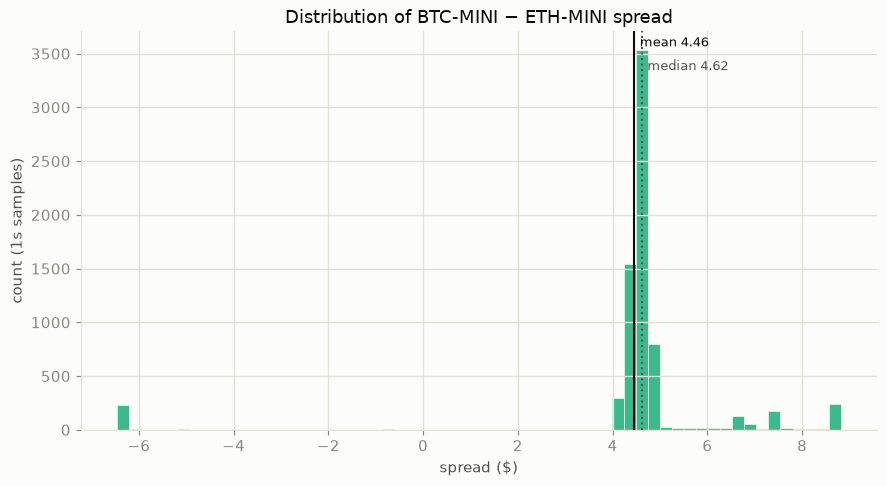

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["spread"], bins=60, color=COLOR_SPREAD, alpha=0.85, edgecolor=SURFACE, linewidth=0.5)

mean_spread = df["spread"].mean()
median_spread = df["spread"].median()
ax.axvline(mean_spread, color=INK_PRIMARY, linewidth=1.5, linestyle="-")
ax.annotate(f"mean {mean_spread:.2f}", xy=(mean_spread, ax.get_ylim()[1]), xytext=(4, -4),
            textcoords="offset points", fontsize=9, color=INK_PRIMARY, va="top")
ax.axvline(median_spread, color=INK_SECONDARY, linewidth=1.5, linestyle=":")
ax.annotate(f"median {median_spread:.2f}", xy=(median_spread, ax.get_ylim()[1]), xytext=(4, -20),
            textcoords="offset points", fontsize=9, color=INK_SECONDARY, va="top")

ax.set_xlabel("spread ($)")
ax.set_ylabel("count (1s samples)")
ax.set_title("Distribution of BTC-MINI − ETH-MINI spread")
fig.tight_layout()
plt.show()

## Summary statistics

In [15]:
spread = df["spread"]

stats = pd.Series({
    "count": spread.count(),
    "mean": spread.mean(),
    "std": spread.std(),
    "min": spread.min(),
    "p5": spread.quantile(0.05),
    "p25": spread.quantile(0.25),
    "median": spread.median(),
    "p75": spread.quantile(0.75),
    "p95": spread.quantile(0.95),
    "max": spread.max(),
    "skew": spread.skew(),
    "kurtosis (excess)": spread.kurt(),
})
print(stats.to_frame("value").to_string(float_format=lambda v: f"{v:.4f}"))

                      value
count             7201.0000
mean                 4.4561
std                  2.2946
min                 -6.4654
p5                   4.1749
p25                  4.4408
median               4.6161
p75                  4.7165
p95                  7.4638
max                  8.8164
skew                -3.3534
kurtosis (excess)   14.5593


## Talking points

- The spread doesn't sit at a constant level — it drifts continuously (pure GBM noise on each leg, uncorrelated) and occasionally jumps (the injected events).
- **Excess kurtosis > 0** here is the injected events doing their job: fatter tails than a clean Gaussian, because most of the distribution is calm random-walk noise with a few discrete regime shifts sitting away from the center. Live data may or may not show this as cleanly — that's real signal, not a scripting artifact.
- The `spread invert` event is the one to point at explicitly: the spread crosses zero and holds there for a while before decaying back. That's the shape a real regime change would have, not a single-tick anomaly.
- **The signal (`z`-score mean-reversion) recovers the same events without being told where they are** — it's fed nothing but the spread series itself. That's the validation that matters: a rule built purely from the spread's own rolling statistics independently flags the same moments a presenter scripted in. Point at this explicitly — it's the difference between "I drew some lines" and "the data itself says something happened here."
- The rule as written (`ENTRY_Z=2`, `EXIT_Z=0.5`, 5-minute rolling window) is a starting point, not a finished strategy — no transaction costs, no slippage, no fill-probability modeling, and it was tuned by eye against one 2-hour sample. Notebook 2 is where this gets wired up to the actual exchange API and tested against real fills.
- This dataset is fully synthetic — regenerate with `python3 generate_data.py` (edit the seed or the `SCHEDULED_EVENTS` list in that file for a different draw) any time you want a fresh rehearsal sample.

In [16]:
ROLLING_WINDOW = 300  # 5 minutes of 1s samples
ENTRY_Z = 2.0
EXIT_Z = 0.5

roll_mean = df["spread"].rolling(ROLLING_WINDOW, min_periods=ROLLING_WINDOW).mean()
roll_std = df["spread"].rolling(ROLLING_WINDOW, min_periods=ROLLING_WINDOW).std()
df["z"] = (df["spread"] - roll_mean) / roll_std

# Stateful signal: +1 = long BTC-MINI / short ETH-MINI, -1 = short BTC-MINI /
# long ETH-MINI, 0 = flat. Holds the current state until an exit or a flip
# condition is hit, rather than re-deciding from z alone on every row.
position = 0
signal = np.zeros(len(df), dtype=int)
z_values = df["z"].to_numpy()
for i, z in enumerate(z_values):
    if np.isnan(z):
        signal[i] = position
        continue
    if position == 0:
        if z > ENTRY_Z:
            position = -1  # spread too wide -> short BTC, long ETH
        elif z < -ENTRY_Z:
            position = 1  # spread too narrow/negative -> long BTC, short ETH
    else:
        if abs(z) < EXIT_Z:
            position = 0
    signal[i] = position

df["signal"] = signal

n_long = (df["signal"] == 1).sum()
n_short = (df["signal"] == -1).sum()
n_flat = (df["signal"] == 0).sum()
print(f"long BTC-MINI / short ETH-MINI:  {n_long:5d} samples ({n_long / len(df):.1%})")
print(f"short BTC-MINI / long ETH-MINI:  {n_short:5d} samples ({n_short / len(df):.1%})")
print(f"flat:                            {n_flat:5d} samples ({n_flat / len(df):.1%})")

long BTC-MINI / short ETH-MINI:   1042 samples (14.5%)
short BTC-MINI / long ETH-MINI:   2302 samples (32.0%)
flat:                             3857 samples (53.6%)


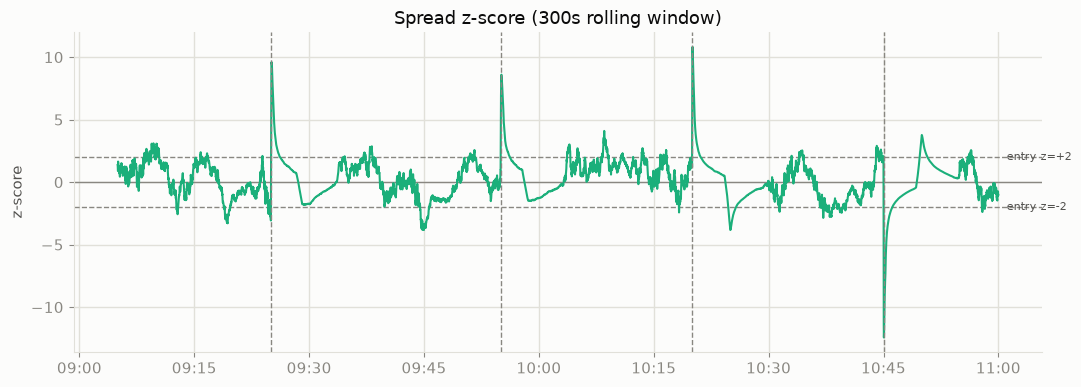

In [17]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.axhline(0, color=INK_MUTED, linewidth=1)
ax.axhline(ENTRY_Z, color=INK_MUTED, linewidth=1, linestyle="--")
ax.axhline(-ENTRY_Z, color=INK_MUTED, linewidth=1, linestyle="--")
ax.annotate(f"entry z=+{ENTRY_Z:.0f}", xy=(df.index[-1], ENTRY_Z), xytext=(6, 0),
            textcoords="offset points", fontsize=8, color=INK_SECONDARY, va="center")
ax.annotate(f"entry z=-{ENTRY_Z:.0f}", xy=(df.index[-1], -ENTRY_Z), xytext=(6, 0),
            textcoords="offset points", fontsize=8, color=INK_SECONDARY, va="center")

ax.plot(df.index, df["z"], color=COLOR_SPREAD, linewidth=1.5)

for t, label in zip(event_times, event_labels):
    ax.axvline(t, color=INK_MUTED, linestyle="--", linewidth=1)

ax.set_ylabel("z-score")
ax.set_title(f"Spread z-score ({ROLLING_WINDOW}s rolling window)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.tight_layout()
plt.show()

### Where the rule would have put you

Shading shows the position the rule would be holding, directly on the spread chart — green for long BTC-MINI / short ETH-MINI, red for the opposite. This is deliberately the finance convention (green = long, red = short), not a generic categorical color.

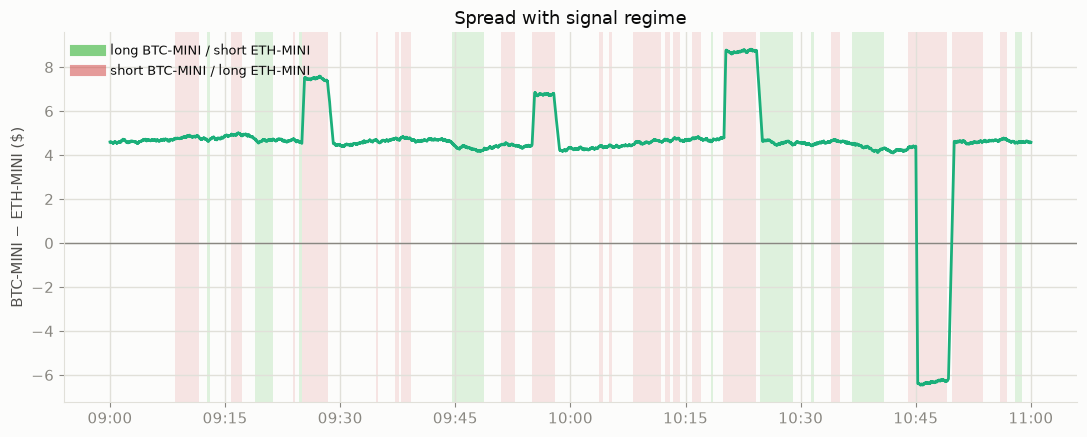

In [18]:
LONG_COLOR = "#0ca30c"
SHORT_COLOR = "#d03b3b"

fig, ax = plt.subplots(figsize=(11, 4.5))

# Shade contiguous same-signal runs as background spans.
sig = df["signal"].to_numpy()
idx = df.index
run_start = 0
for i in range(1, len(sig) + 1):
    if i == len(sig) or sig[i] != sig[run_start]:
        if sig[run_start] != 0:
            color = LONG_COLOR if sig[run_start] == 1 else SHORT_COLOR
            ax.axvspan(idx[run_start], idx[i - 1], color=color, alpha=0.12, linewidth=0)
        run_start = i

ax.axhline(0, color=INK_MUTED, linewidth=1)
ax.plot(df.index, df["spread"], color=COLOR_SPREAD, linewidth=2)

ax.plot([], [], color=LONG_COLOR, linewidth=8, alpha=0.5, label="long BTC-MINI / short ETH-MINI")
ax.plot([], [], color=SHORT_COLOR, linewidth=8, alpha=0.5, label="short BTC-MINI / long ETH-MINI")

ax.set_ylabel("BTC-MINI − ETH-MINI ($)")
ax.set_title("Spread with signal regime")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(frameon=False, loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

In [19]:
# Concrete episodes: every contiguous long/short run, with what to hold and for how long.
episodes = []
run_start = 0
for i in range(1, len(sig) + 1):
    if i == len(sig) or sig[i] != sig[run_start]:
        if sig[run_start] != 0:
            direction = "long BTC-MINI / short ETH-MINI" if sig[run_start] == 1 else "short BTC-MINI / long ETH-MINI"
            episodes.append({
                "start": idx[run_start],
                "end": idx[i - 1],
                "duration_s": int((idx[i - 1] - idx[run_start]).total_seconds()),
                "position": direction,
            })
        run_start = i

episodes_df = pd.DataFrame(episodes)
episodes_df

,start,end,duration_s,position
0,2026-09-07 09:08:29,2026-09-07 09:11:33,184,short BTC-MINI / long ETH-MINI
1,2026-09-07 09:12:42,2026-09-07 09:13:05,23,long BTC-MINI / short ETH-MINI
2,2026-09-07 09:15:47,2026-09-07 09:17:14,87,short BTC-MINI / long ETH-MINI
3,2026-09-07 09:18:54,2026-09-07 09:21:11,137,long BTC-MINI / short ETH-MINI
4,2026-09-07 09:23:54,2026-09-07 09:24:03,9,short BTC-MINI / long ETH-MINI
5,2026-09-07 09:24:40,2026-09-07 09:25:00,20,long BTC-MINI / short ETH-MINI
6,2026-09-07 09:25:02,2026-09-07 09:28:24,202,short BTC-MINI / long ETH-MINI
7,2026-09-07 09:34:37,2026-09-07 09:34:59,22,short BTC-MINI / long ETH-MINI
8,2026-09-07 09:37:07,2026-09-07 09:37:42,35,short BTC-MINI / long ETH-MINI
9,2026-09-07 09:37:53,2026-09-07 09:39:12,79,short BTC-MINI / long ETH-MINI


## Talking points

- The spread doesn't sit at a constant level — it drifts continuously (pure GBM noise on each leg, uncorrelated) and occasionally jumps (the injected events).
- **Excess kurtosis > 0** here is the injected events doing their job: fatter tails than a clean Gaussian, because most of the distribution is calm random-walk noise with a few discrete regime shifts sitting away from the center. Live data may or may not show this as cleanly — that's real signal, not a scripting artifact.
- The `spread invert` event is the one to point at explicitly: the spread crosses zero and holds there for a while before decaying back. That's the shape a real regime change would have, not a single-tick anomaly.
- This dataset is fully synthetic and reseeded per run (`random.seed(7)` above) — rerun the generation cell with a different seed (or no seed) for a fresh draw if you want variety across rehearsals.